# Lab 5

Helper code for plotting, lab starts below!

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def dodge_y(points, point_size, padding=0.0, anchor="bottom"):
    points = np.asarray(points)

    if points.ndim == 1:
        x = points.astype(float, copy=False)
    elif points.ndim == 2 and points.shape[1] >= 1:
        x = points[:, 0].astype(float, copy=False)
    else:
        raise ValueError(
            "points must be a 1D array of x positions or a 2D array with x in the first column"
        )

    if point_size < 0 or padding < 0:
        raise ValueError("point_size and padding must be non-negative")
    if anchor not in {"bottom", "middle", "top"}:
        raise ValueError("anchor must be 'bottom', 'middle', or 'top'")

    n = x.shape[0]
    y = np.zeros(n, dtype=float)
    separation = float(point_size + padding)

    if n == 0 or separation == 0:
        return y

    sep2 = separation * separation
    tol = 1e-12
    buckets = {}

    def pick_generic(dx, active_y):
        dy = np.sqrt(np.maximum(sep2 - dx * dx, 0.0))
        candidates = np.empty(2 * dx.size + 1, dtype=float)
        candidates[0] = 0.0
        candidates[1::2] = active_y - dy
        candidates[2::2] = active_y + dy

        best = None
        for yc in candidates:
            if anchor == "bottom" and yc < -tol:
                continue
            if anchor == "top" and yc > tol:
                continue

            if np.all(dx * dx + (yc - active_y) ** 2 >= sep2 - tol):
                yc = float(yc)
                if best is None:
                    best = yc
                elif anchor == "middle" and (abs(yc), yc) < (abs(best), best):
                    best = yc
                elif anchor == "bottom" and yc < best:
                    best = yc
                elif anchor == "top" and yc > best:
                    best = yc

        if best is None:
            raise RuntimeError("failed to place a point without overlap")
        return best

    for i, xi in enumerate(x):
        bucket = int(np.floor(xi / separation))
        neighbor_indices = []
        for b in (bucket - 1, bucket, bucket + 1):
            neighbor_indices.extend(buckets.get(b, ()))

        if neighbor_indices:
            active_idx = np.array(neighbor_indices, dtype=int)
            dx = xi - x[active_idx]
            keep = np.abs(dx) < separation
            active_idx = active_idx[keep]
            dx = dx[keep]

            if dx.size:
                active_y = y[active_idx]
                dy = np.sqrt(np.maximum(sep2 - dx * dx, 0.0))
                lower = active_y - dy
                upper = active_y + dy

                if anchor == "bottom":
                    yi = 0.0
                    while True:
                        blocked = (lower - tol <= yi) & (yi < upper - tol)
                        if not np.any(blocked):
                            break
                        yi = float(np.max(upper[blocked]))
                    y[i] = yi
                elif anchor == "top":
                    yi = 0.0
                    while True:
                        blocked = (lower + tol < yi) & (yi <= upper + tol)
                        if not np.any(blocked):
                            break
                        yi = float(np.min(lower[blocked]))
                    y[i] = yi
                else:
                    y[i] = pick_generic(dx, active_y)

        buckets.setdefault(bucket, []).append(i)

    return y


def patch_scatter(x, y, radius, ax=None, facecolor="C0", **kwargs):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape")
    if radius < 0:
        raise ValueError("radius must be non-negative")

    if ax is None:
        ax = plt.gca()

    patches = []
    for i, (xi, yi) in enumerate(zip(x.ravel(), y.ravel())):
        if facecolor is not None and isinstance(facecolor, np.ndarray):
            color = cmap = plt.get_cmap('tab10')(facecolor.ravel().astype(int)[i] % 10)
        else:
            color = facecolor
        patch = Circle((xi, yi), radius=radius, facecolor=color, **kwargs)
        ax.add_patch(patch)
        patches.append(patch)

    ax.autoscale_view()
    return ax, patches


def plotDataAndPdf(data=None, pdf=None, xlim=None, ax=None, datacolor="C0", pdfcolor="C1"):
    fig, ax = plt.subplots(figsize=(10, 3)) if ax is None else (ax.figure, ax)

    if not data is None:
        npoints = data.size()[0]
        min_x = data.min()
        max_x = data.max()
        width = max_x - min_x
        min_x -= 0.1 * width
        max_x += 0.1 * width

        radius = 5 *(width.item() / (npoints))
        
        data = torch.tensor(data).detach().cpu().numpy()
        datay = dodge_y(data, point_size=2. * radius)
        patch_scatter(data, datay, radius=radius, ax=ax, facecolor=datacolor)
        ax.set_aspect("equal")
        ax.yaxis.set_visible(False)
    else:
        min_x = -5
        max_x = 5
        npoints = 1
        radius = 1 / 2.25

    if xlim is not None:
        min_x, max_x = xlim
        ax.set_xlim(min_x, max_x)

    if not pdf is None:
        x = torch.linspace(min_x, max_x, 300)
        y = pdf(x).detach().cpu().numpy()
        x = x.detach().cpu().numpy()
        plt.plot(x, y * npoints * (2.25 * radius) ** 2, c=pdfcolor)

    plt.show()

## Part 1: A distribution class

We'll start by looking at a simple Python class that represents a probability distribution. There's 2 main things we'll want to do with a distribution.

- 1) Draw samples from it
- 2) Compute the probability of a given outcome (or the probability *density* at a given outcome in the case of the Normal distribution).

Below we've setup a base class for distributions as well as two concrete examples for us to work with. We'll start by focusing on the Normal distribution. Recall that we can write the probability density function for a Normal distribution as:

$$p(x) = \mathcal{N}(x; \mu, \sigma) = \frac{1}{\sqrt{2\pi}\sigma}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2} \right)$$

Remember that $\mu$ and $\sigma$ are the *parameters* of the distribution that define a particular Normal distribution's mean and standard deviation. Making our distribution into a class means we can encapsulate these parameters into an object as we would with the parameters of a neural network. In fact, here we've setup the class as a torch module so we'll later be able to easily do gradient descent!

With these paramters our class has methods for computing the (log) probability of an observation and for drawing sample(s). We'll use these basic tools to build more complicated models as we go!

Our categorical distribution is defined similarly, except in this case we have a vector of probabilities $\mathbf{\hat{p}}$ and our probability mass function is:

$$p(z) = \hat{p}_z$$

In [17]:
class Distribution:
    def __init__(self):
        super().__init__()

    def prob(self, x):
        raise NotImplementedError

    def sample(self, size=(1,)):
        raise NotImplementedError
    
    def log_prob(self, x):
        return torch.log(self.prob(x))

class NormalDistribution(Distribution):
    def __init__(self, mu=0.0, sigma=1.0):
        super().__init__()
        self.mu = torch.tensor(mu)
        self.sigma = torch.tensor(sigma)

    def prob(self, x):
        return (1 / (self.sigma * torch.sqrt(torch.tensor(2.0) * torch.pi))) * torch.exp(-0.5 * ((x - self.mu) / self.sigma) ** 2)

    def sample(self, size=(1,)):
        return self.mu + self.sigma * torch.randn(size)

class CategoricalDistribution(Distribution):
    def __init__(self, probs):
        super().__init__()
        self.probs = torch.tensor(probs)

    def prob(self, x):
        return self.probs[x]

    def sample(self, size=(1,)):
        return torch.multinomial(self.probs, num_samples=size[0], replacement=True)

With this setup we can now try sampling from a distribution an plotting the results! We've included a helper function for plotting here.

/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/821287568.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).detach().cpu().numpy()


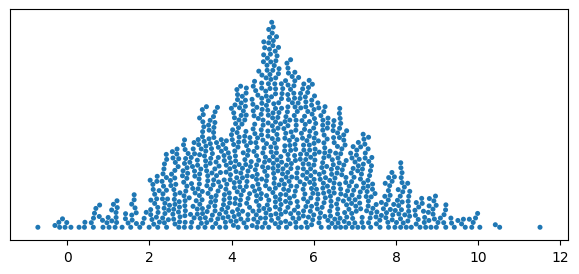

In [18]:
# Create a distribution with mean 5.0 and standard deviation 2.0, then plot 1000 samples
dist = NormalDistribution(mu=5.0, sigma=2.0)
x = dist.sample(size=(1000,))
plotDataAndPdf(x)

We can see that as we pile up the samples, they start to look like a Normal distribution!

We can also plot the PDF of our Normal distribution along with the samples and see how well it matches:

/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/821287568.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).detach().cpu().numpy()


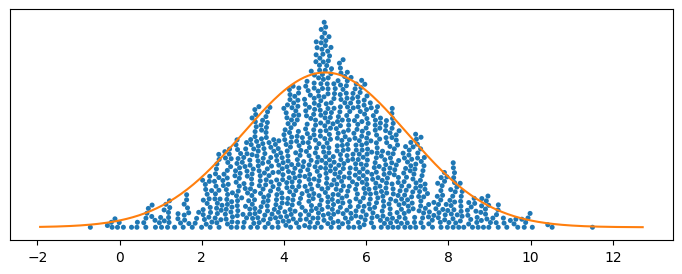

In [19]:
plotDataAndPdf(x, pdf=dist.prob)

Pretty good! We see that there are more samples in regions where the probability density it higher!

Ok, but this wouldn't be machine learning without some form of learning. So our next step is to be able to find $\mu$ and $\sigma$ given a dataset. Then we can use it to try and replicate that dataset. Do do this our typical approach is to use *maximum likelihood estimation*, which just means choosing $\mu$ and $\sigma$ so that $p(x)$ is as large as possible for out data. Specifically we want:

$$\max_{\mu, \sigma} \prod_{i=1}^N p(x_i)$$

Recall that we can more conviniently solve the equivalent problem (negative log-likelihood):

$$\min_{\mu, \sigma} -\sum_{i=1}^N \log p(x_i)$$


#### **Q1** Normal MLE

Using the solution we derived in class, write a function to find the MLE of a Normal distribution from data. The function should take in a dataset as a torch tensor and return a `NormalDistribution` object with the optimal $\mu$ and $\sigma$.

*You should **not** need gradient descent for this!*

/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/146329540.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mu = torch.tensor(mu)
/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/146329540.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.sigma = torch.tensor(sigma)
/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/821287568.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).detach().cpu().numpy()


MLE mean: 5.08, MLE std: 1.95


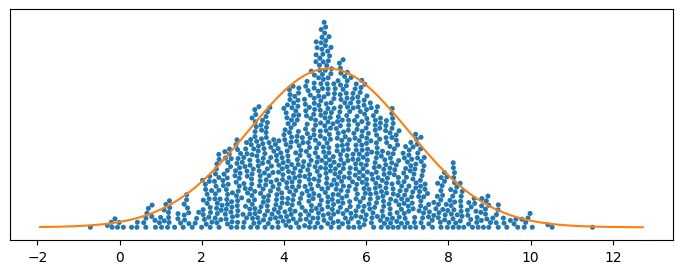

tensor(2086.7993)


In [20]:
def normalMLE(data):
    ret = NormalDistribution(mu=torch.mean(data), sigma=(torch.sum((data-torch.mean(data))**2)/torch.numel(data))**(1/2))
    
    return ret

# Test your MLE implementation by fitting a normal distribution to the data and plotting the result
mle_dist = normalMLE(x)
print(f"MLE mean: {mle_dist.mu.item():.2f}, MLE std: {mle_dist.sigma.item():.2f}")
plotDataAndPdf(x, pdf=mle_dist.prob)
print(-mle_dist.log_prob(x).sum())

Now let's look at a slightly more interesting dataset:

/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/821287568.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).detach().cpu().numpy()


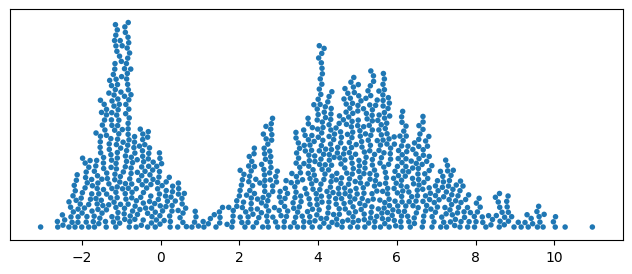

In [21]:
x2 = torch.cat([torch.randn(700) * 2 + 5, torch.randn(300) * 0.75 - 1])
plotDataAndPdf(x2)

#### **Q2** Normal MLE test

Try out your normal MLE on this new dataset and plot the result. Then compare the log-likelihood of the MLE on this dataset to the log-likelihood of the MLE for the previous dataset. What do you notice?

The negative log likelihood of the second distribution is higher than the first, meaning that it fits the data less well. This seems to be intuitively correct as the data in the second dataset seems to conform less to a normal distribution.

/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/146329540.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mu = torch.tensor(mu)
/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/146329540.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.sigma = torch.tensor(sigma)
/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/821287568.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).detach().cpu().numpy()


MLE mean: 3.19, MLE std: 3.21


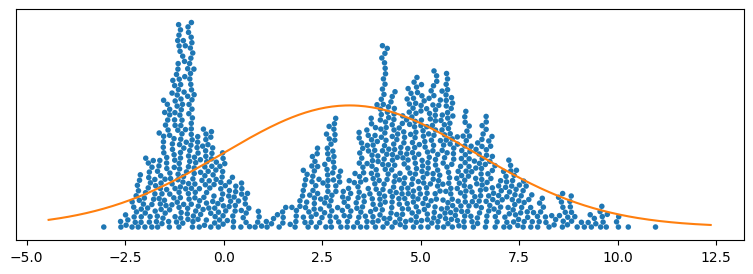

tensor(2584.9897)


In [22]:
mle_dist2 = normalMLE(x2)
print(f"MLE mean: {mle_dist2.mu.item():.2f}, MLE std: {mle_dist2.sigma.item():.2f}")
plotDataAndPdf(x2, pdf=mle_dist2.prob)
print(-mle_dist2.log_prob(x2).sum())

Now to set ourselves up for the next questions, let's try finding the MLE with gradient descent instead of just solving for the optimum. To do this it will help us to update our distribution objects to be PyTorch modules with learnable parameters. 

There's one big caveat that we need to keep in mind as we do this! We have some constraints on what these parameters can be! Recall that $\sigma > 0$ for the Normal distribution and for the categorical, we must have: $\hat{p}_j \geq 0$ and $\sum_{j=1}^k \hat{p}_j =1$. We can enforce constraints like these by applying a function to each parameter before we use it that maps it into the right domain, just like we do for the output prediction of a neural network. For example we might make $\sigma = f(\bar\sigma)$ where $\bar{\sigma}$ is what we learn and $f()$ is a function that maps $(-\infty, \infty)$ to $(0, \infty)$.

#### **Q3** Normal MLE test

Update both distributions below to wrap all parameters in `nn.Parameter` and initialize them randomly. Also modify the `prob` and `sample` functions such that they transform all parameters into a valid domain before using them.

*Hint: think about what functions we know about that can enforce the constraints above. You don't need to worry that the initialization will be a little wrong*

In [23]:
import torch.nn.functional as F

class LearnableDistribution(nn.Module):
    def __init__(self):
        super().__init__()

    def prob(self, x):
        raise NotImplementedError

    def sample(self, size=(1,)):
        raise NotImplementedError
    
    def log_prob(self, x):
        return torch.log(self.prob(x))

class LearnableNormalDistribution(LearnableDistribution):
    def __init__(self):
        super().__init__()
        self.mu = nn.Parameter(torch.randn(1))
        self.sigma = nn.Parameter(torch.randn(1))

    def prob(self, x):
        # Modify this!
        return 1 / (torch.exp(self.sigma) * torch.sqrt(torch.tensor(2.0) * torch.pi)) * torch.exp(-0.5 * ((x - self.mu) / torch.exp(self.sigma)) ** 2)

    def sample(self, size=(1,)):
        # Modify this!
        return self.mu + torch.exp(self.sigma) * torch.randn(size)

class LearnableCategoricalDistribution(LearnableDistribution):
    def __init__(self, num_cat):
        super().__init__()
        self.probs = nn.Parameter(torch.randn(num_cat))

    def prob(self, x):
        # Modify this!
        return F.softmax(self.probs)[x]

    def sample(self, size=(1,)):
        # Modify this!
        probs = F.softmax(self.probs)
        return torch.multinomial(probs, num_samples=size[0], replacement=True)

#### **Q4** Normal MLE with gradient descent

Now complete the function below to learn the MLE parameters of a normal distribution from data with gradient descent. As before the function should take in data and return a `LearnableNormalDistribution` with the correct parameters. Verify that the function works by plotting the result.

MLE mean: 5.08, MLE std: 0.67


/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/821287568.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).detach().cpu().numpy()


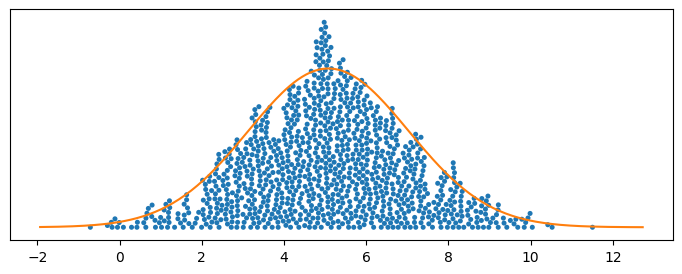

In [31]:
def normalMLE_GD(data):
    model = LearnableNormalDistribution()
    optimizer = optim.SGD(model.parameters(), lr=0.0005)
    for i in range(100):
        predictions = model.prob(data)
        loss = -model.log_prob(data).sum()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    return model
   

# Test your MLE implementation by fitting a normal distribution to the data and plotting the result
mle_dist = normalMLE_GD(x)
print(f"MLE mean: {mle_dist.mu.item():.2f}, MLE std: {mle_dist.sigma.item():.2f}")

plotDataAndPdf(x, pdf=mle_dist.prob)

Now we should have most of the tools we need for fitting a mixture distribution! Let's start by writing a `LearnableNormalMixture` class. This class should take in the number of components to use and store a `nn.ModuleList` with `LearnableNormalDistribution` objects as all of the components, as well as a `LearnableCategoricalDistribution` for the component weights.

#### **Q5** Mixture distribution

Complete the implementation for a mixture distribution below, filling out the prob function according to what we learned in class and filling out the sample function.


/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/1788880954.py:41: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(self.probs)
/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/821287568.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).detach().cpu().numpy()
/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/2946849631.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  compW = F.softmax(self.weights.probs)


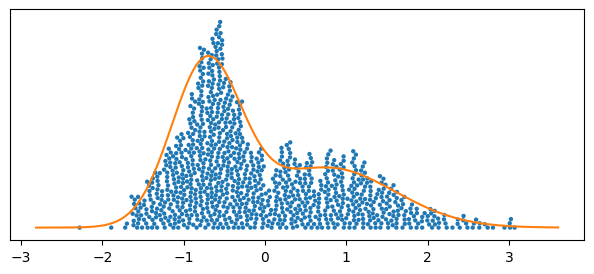

In [36]:
class LearnableNormalMixture(LearnableDistribution):
    def __init__(self, ncomponents):
        super().__init__()
        # YOUR CODE HERE
        self.components = nn.ModuleList([LearnableNormalDistribution() for i in range(ncomponents)])
        self.weights = LearnableCategoricalDistribution(ncomponents)

    def prob(self, x):
        compW = F.softmax(self.weights.probs)
        pred = [self.components[i].prob(x)*compW[i] for i in range(len(compW))]
        pred = sum(pred)
        
        
        return pred

    def sample(self, size=(1,)):
        compW = self.weights.sample(size)
        
        samples = [self.components[compW[i]].sample() for i in range(len(compW))]
        
        return torch.tensor(samples)

# Try plotting a randomly initialized learnable normal mixture model
dist = LearnableNormalMixture(ncomponents=2)
plotDataAndPdf(dist.sample(size=(1000,)), pdf=dist.prob)

#### **Q6** Mixture MLE

Finally, let's fit our mixture distribution with maximum likelihood estimation and gradient descent. Complete the `normalMixtureMLE` function below to find the optimal parameters with graident descent. You should return a `LearnableNormalMixture` object with the optimal parameters.

*Optionally also plot the loss as a function of iterations.*

/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/2946849631.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  compW = F.softmax(self.weights.probs)
/var/folders/82/9wzdp9r94lsbg_dvhkktjg8c0000gn/T/ipykernel_51612/821287568.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).detach().cpu().numpy()


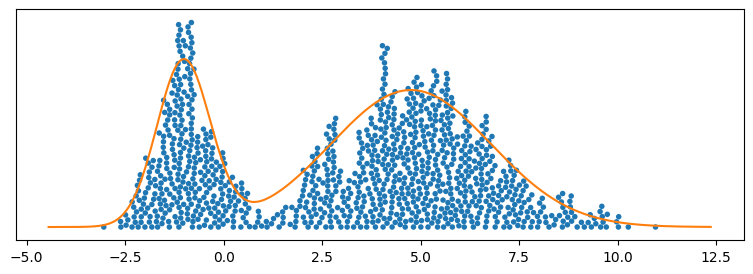

In [38]:
def normalMixtureMLE(data, n_components, plot=True):
    model = LearnableNormalMixture(2)
    optimizer = optim.SGD(model.parameters(), lr=0.0005)
    for i in range(100):
        predictions = model.prob(data)
        loss = -model.log_prob(data).sum()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    return model
    
# Test your MLE implementation by fitting a normal mixture model to the data and plotting the result
mle_mixture = normalMixtureMLE(x2, n_components=2)
plotDataAndPdf(x2, pdf=mle_mixture.prob)